# Unità 1 : BB84 ideale


## 1. Obiettivo

Questo notebook simula il protocollo BB84 in condizioni ideali: Alice prepara qubit BB84, Bob misura in una base scelta casualmente e i round vengono filtrati tramite sifting. Non sono inclusi Eve, intercettazione, rumore o decoerenza.


In [12]:
from pathlib import Path
import sys

current_path = Path.cwd().resolve()

if (current_path / "src" / "qkd_utils.py").exists():
    project_root = current_path
elif (current_path.parent / "src" / "qkd_utils.py").exists():
    project_root = current_path.parent
else:
    raise FileNotFoundError(
        "src/qkd_utils.py non trovato. Eseguire il notebook "
        "dalla root del progetto oppure dalla cartella notebooks."
    )

src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Root del progetto: {project_root}")
print(f"Percorso src aggiunto: {src_path}")

Root del progetto: C:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project
Percorso src aggiunto: C:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\src


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit

from bb84 import (
    random_bits,
    random_bases,
    prepare_bb84_state,
    measure_bb84_state,
    run_bb84_round,
    run_bb84_protocol,
    sift_keys,
    compute_qber,
)
from plots import plot_keep_discard
from utils import save_table

print("Import completati.")


## 2. Convenzioni usate

- I bit classici sono `0` e `1`.
- Le basi BB84 sono `"Z"` e `"X"`.
- In base `Z`: `0 -> |0>` e `1 -> |1>`.
- In base `X`: `0 -> |+>` e `1 -> |->`.
- La misura in `Z` è la misura computazionale standard.
- La misura in `X` applica un gate Hadamard prima della misura computazionale.


## 3. Check delle funzioni base

Verifichiamo generazione casuale, preparazione degli stati e misura nelle basi BB84.


In [13]:
bits = random_bits(10, seed=1)
bases = random_bases(10, seed=1)

print("bit:", bits)
print("basi:", bases)

assert len(bits) == 10
assert len(bases) == 10
assert all(bit in [0, 1] for bit in bits)
assert all(basis in ["Z", "X"] for basis in bases)

print("Check 1 superato.")


bit: [0, 1, 1, 1, 0, 0, 1, 1, 0, 0]
basi: ['Z', 'X', 'X', 'X', 'Z', 'Z', 'X', 'X', 'Z', 'Z']
Check 1 superato.


In [14]:
cases = [
    (0, "Z", "|0>"),
    (1, "Z", "|1>"),
    (0, "X", "|+>"),
    (1, "X", "|->"),
]

for bit, basis, label in cases:
    qc = QuantumCircuit(1, 1)
    prepare_bb84_state(qc, bit=bit, basis=basis)

    print(f"\nCaso: bit={bit}, base={basis}, stato atteso={label}")
    print(qc)



Caso: bit=0, base=Z, stato atteso=|0>
     
  q: 
     
c: 1/
     

Caso: bit=1, base=Z, stato atteso=|1>
     ┌───┐
  q: ┤ X ├
     └───┘
c: 1/═════
          

Caso: bit=0, base=X, stato atteso=|+>
     ┌───┐
  q: ┤ H ├
     └───┘
c: 1/═════
          

Caso: bit=1, base=X, stato atteso=|->
     ┌───┐┌───┐
  q: ┤ X ├┤ H ├
     └───┘└───┘
c: 1/══════════
               


In [15]:
qc = QuantumCircuit(1, 1)

prepare_bb84_state(qc, bit=1, basis="X")
measure_bb84_state(qc, basis="X")

print(qc)


     ┌───┐┌───┐┌───┐┌─┐
  q: ┤ X ├┤ H ├┤ H ├┤M├
     └───┘└───┘└───┘└╥┘
c: 1/════════════════╩═
                     0 


In [16]:
invalid_bit_raised = False
invalid_basis_raised = False

try:
    qc = QuantumCircuit(1, 1)
    prepare_bb84_state(qc, bit=2, basis="Z")
except Exception as e:
    invalid_bit_raised = True
    print("Bit non valido rifiutato correttamente:", type(e).__name__, "-", e)

try:
    qc = QuantumCircuit(1, 1)
    prepare_bb84_state(qc, bit=0, basis="Y")
except Exception as e:
    invalid_basis_raised = True
    print("Base non valida rifiutata correttamente:", type(e).__name__, "-", e)

assert invalid_bit_raised
assert invalid_basis_raised

print("Check 4 superato.")


Bit non valido rifiutato correttamente: ValueError - bit must be 0 or 1.
Base non valida rifiutata correttamente: ValueError - basis must be 'Z' or 'X'.
Check 4 superato.


## 4. Simulazione di un singolo round

Quando Alice e Bob usano la stessa base, il bit misurato da Bob coincide con quello preparato da Alice.


In [17]:
bob_bit_0 = run_bb84_round(alice_bit=0, alice_basis="Z", bob_basis="Z")
print("Bit di Bob per bit Alice 0 in Z/Z:", bob_bit_0)
assert bob_bit_0 == 0

bob_bit_1 = run_bb84_round(alice_bit=1, alice_basis="Z", bob_basis="Z")
print("Bit di Bob per bit Alice 1 in Z/Z:", bob_bit_1)
assert bob_bit_1 == 1

print("Check sul singolo round superato.")


Bit di Bob per bit Alice 0 in Z/Z: 0
Bit di Bob per bit Alice 1 in Z/Z: 1
Check sul singolo round superato.


## 5. Simulazione multi-round

Eseguiamo il protocollo BB84 ideale su `n_rounds = 200` con `seed = 123`.


In [18]:
n_rounds = 200
seed = 123

results_df = run_bb84_protocol(n_rounds=n_rounds, seed=seed)

expected_columns = [
    "round",
    "alice_bit",
    "alice_basis",
    "bob_basis",
    "bob_bit",
    "keep",
]

assert list(results_df.columns) == expected_columns
assert (results_df["keep"] == (results_df["alice_basis"] == results_df["bob_basis"])).all()

print("Simulazione completata.")
print("Righe:", len(results_df))


Simulazione completata.
Righe: 200


## 6. Sifting e QBER

Conserviamo solo i round in cui Alice e Bob hanno scelto la stessa base e calcoliamo il QBER sulla chiave sifted.


In [19]:
alice_key, bob_key = sift_keys(results_df)
qber = compute_qber(alice_key, bob_key)

total_rounds = len(results_df)
kept_rounds = int(results_df["keep"].sum())
discarded_rounds = total_rounds - kept_rounds
sifted_key_length = len(alice_key)

summary_df = pd.DataFrame(
    {
        "metric": [
            "round totali",
            "round mantenuti",
            "round scartati",
            "lunghezza chiave sifted",
            "QBER",
        ],
        "value": [
            total_rounds,
            kept_rounds,
            discarded_rounds,
            sifted_key_length,
            qber,
        ],
    }
)

display(summary_df)

assert len(alice_key) == len(bob_key)
assert qber == 0.0


,metric,value
0,round totali,200.0
1,round mantenuti,105.0
2,round scartati,95.0
3,lunghezza chiave sifted,105.0
4,QBER,0.0


## 7. Tabella dei risultati

Mostriamo le prime 20 righe e salviamo il DataFrame completo in CSV.


In [20]:
display(results_df.head(20))

table_path = project_root / "results" / "tables" / "bb84_ideal_results.csv"
save_table(results_df, table_path)

print("Tabella salvata in:", table_path)


,round,alice_bit,alice_basis,bob_basis,bob_bit,keep
0,1,0,X,Z,0,False
1,2,1,X,X,1,True
2,3,1,X,Z,0,False
3,4,0,X,Z,0,False
4,5,1,X,Z,0,False
5,6,0,X,Z,0,False
6,7,0,Z,X,0,False
7,8,0,X,Z,0,False
8,9,0,X,X,0,True
9,10,0,X,Z,0,False


Tabella salvata in: C:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\bb84_ideal_results.csv


## 8. Grafico keep/discard

Il grafico confronta i round mantenuti con quelli scartati durante il sifting.


Figura salvata in: C:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_ideal_keep_discard.png


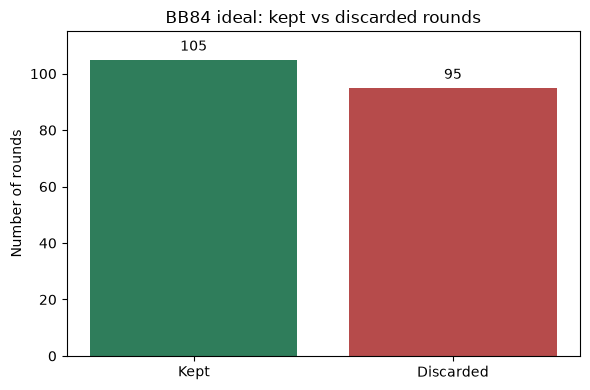

In [22]:
figure_path = project_root / "results" / "figures" / "bb84_ideal_keep_discard.png"
fig, ax = plot_keep_discard(results_df, path=figure_path)

print("Figura salvata in:", figure_path)
plt.show()


## 9. Interpretazione

Quando Alice e Bob scelgono la stessa base, il bit misurato da Bob è compatibile con lo stato preparato da Alice e il round viene conservato. Quando scelgono basi diverse, il risultato di Bob non è utile per costruire la chiave condivisa e il round viene scartato. In assenza di Eve e rumore, dopo il sifting Alice e Bob condividono la stessa chiave e il QBER risulta `0.0`.
